In [2]:
import palantir
import scanpy as sc
import numpy as np
import pandas as pd
import os

# Plotting 
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Inline Plotting
%matplotlib inline

sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['image.cmap'] = 'Spectral_r'
warnings.filterwarnings(action="ignore", module="matplotlib", message="findfont")

# Reset Random Seed
np.random.seed(5)

# Working Direction
wdir = "/media/desk16/iyun4605/projects/Everolimus_Resistance_ccRCC/analysis/data/07_mps_trajectory/02_Palantir"
os.chdir(wdir)
print(os.getcwd())

/media/desk16/iyun4605/projects/Everolimus_Resistance_ccRCC/analysis/data/07_mps_trajectory/02_Palantir


In [9]:
adata = sc.read_h5ad("01_mps_scaled_adata.h5ad")
adata

AnnData object with n_obs × n_vars = 12912 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'contamination_score', 'contamination_th_0.1', 'contamination_th_0.2', 'doublet_score', 'predicted_doublet', 'percent_mito_by_sample', 'percent_ribo_by_sample', 'percent_hb_by_sample', 'percent_hsp_by_sample', 'percent_dissociation_by_sample', 'RNA_snn_res.0.1', 'RNA_snn_res.0.15', 'RNA_snn_res.0.2', 'RNA_snn_res.0.25', 'RNA_snn_res.0.3', 'RNA_snn_res.0.35', 'RNA_snn_res.0.4', 'RNA_snn_res.0.45', 'RNA_snn_res.0.5', 'seurat_clusters', 'ERScore', 'ERScore_group', 'major_celltype_treat', 'MPS_RNA_snn_res.0.1', 'MPS_RNA_snn_res.0.15', 'MPS_RNA_snn_res.0.2', 'MPS_RNA_snn_res.0.25', 'MPS_RNA_snn_res.0.3', 'MPS_RNA_snn_res.0.35', 'MPS_RNA_snn_res.0.4', 'MPS_RNA_snn_res.0.45', 'MPS_RNA_snn_res.0.5', 'MPS_RNA_snn_res.0.55', 'MPS_RNA_snn_res.0.6', 'MPS_RNA_snn_res.0.65', 'MPS_RNA_snn_res.0.7', 'MPS_RNA_snn_res.0.75', 'MPS_RNA_snn_res.0.8', 'MPS_RNA_snn_res.0.85', 'MPS_RNA_snn_res.0.9', 'MPS_RNA

In [10]:
sc.tl.pca(adata, n_comps=30)
sc.external.pp.harmony_integrate(adata, key="orig.ident", basis='X_pca')
adata.obsm

2026-02-21 21:07:10,622 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-02-21 21:07:13,809 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-02-21 21:07:13,932 - harmonypy - INFO - Iteration 1 of 10
2026-02-21 21:07:20,253 - harmonypy - INFO - Iteration 2 of 10
2026-02-21 21:07:27,063 - harmonypy - INFO - Iteration 3 of 10
2026-02-21 21:07:33,601 - harmonypy - INFO - Iteration 4 of 10
2026-02-21 21:07:40,032 - harmonypy - INFO - Iteration 5 of 10
2026-02-21 21:07:45,229 - harmonypy - INFO - Iteration 6 of 10
2026-02-21 21:07:49,216 - harmonypy - INFO - Iteration 7 of 10
2026-02-21 21:07:52,512 - harmonypy - INFO - Iteration 8 of 10
2026-02-21 21:07:55,236 - harmonypy - INFO - Iteration 9 of 10
2026-02-21 21:07:58,028 - harmonypy - INFO - Iteration 10 of 10
2026-02-21 21:08:00,428 - harmonypy - INFO - Stopped before convergence


AxisArrays with keys: X_harmony, X_pca, X_umap, X_pca_harmony

In [11]:
pca_projections = pd.DataFrame(adata.obsm['X_pca_harmony'], index=adata.obs_names)
pca_projections.shape

(12912, 30)

In [12]:
dm_res = palantir.utils.run_diffusion_maps(pca_projections, n_components=10)
ms_data = palantir.utils.determine_multiscale_space(dm_res)
ms_data.shape
early_cell = 'RCC114_CGGCAGTTCGCGTGCA-1'
pr_res = palantir.core.run_palantir(ms_data, early_cell=early_cell, use_early_cell_as_start=True, num_waypoints=500, knn=30)

Sampling and flocking waypoints...
Time for determining waypoints: 0.011208788553873698 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.14272863070170086 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9994
Correlation at iteration 2: 0.9999
Correlation at iteration 3: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [13]:
adata.obs['pseudotime'] = pr_res.pseudotime
adata.obs["DP"] = pr_res.entropy
adata

AnnData object with n_obs × n_vars = 12912 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'contamination_score', 'contamination_th_0.1', 'contamination_th_0.2', 'doublet_score', 'predicted_doublet', 'percent_mito_by_sample', 'percent_ribo_by_sample', 'percent_hb_by_sample', 'percent_hsp_by_sample', 'percent_dissociation_by_sample', 'RNA_snn_res.0.1', 'RNA_snn_res.0.15', 'RNA_snn_res.0.2', 'RNA_snn_res.0.25', 'RNA_snn_res.0.3', 'RNA_snn_res.0.35', 'RNA_snn_res.0.4', 'RNA_snn_res.0.45', 'RNA_snn_res.0.5', 'seurat_clusters', 'ERScore', 'ERScore_group', 'major_celltype_treat', 'MPS_RNA_snn_res.0.1', 'MPS_RNA_snn_res.0.15', 'MPS_RNA_snn_res.0.2', 'MPS_RNA_snn_res.0.25', 'MPS_RNA_snn_res.0.3', 'MPS_RNA_snn_res.0.35', 'MPS_RNA_snn_res.0.4', 'MPS_RNA_snn_res.0.45', 'MPS_RNA_snn_res.0.5', 'MPS_RNA_snn_res.0.55', 'MPS_RNA_snn_res.0.6', 'MPS_RNA_snn_res.0.65', 'MPS_RNA_snn_res.0.7', 'MPS_RNA_snn_res.0.75', 'MPS_RNA_snn_res.0.8', 'MPS_RNA_snn_res.0.85', 'MPS_RNA_snn_res.0.9', 'MPS_RNA

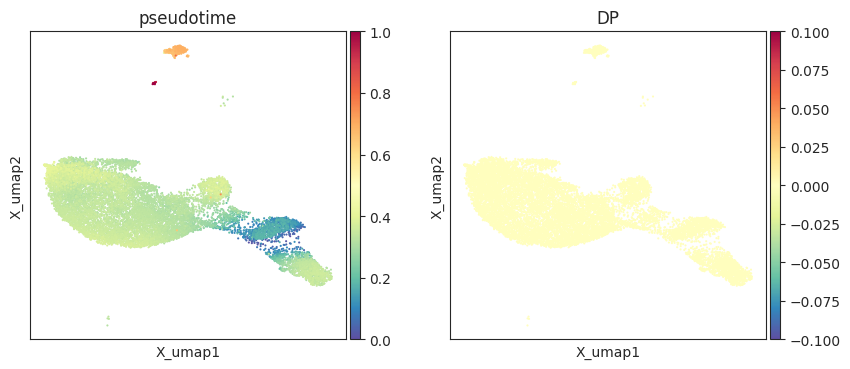

In [14]:
sc.pl.embedding(adata, basis="X_umap", color=['pseudotime', 'DP'])

In [9]:
adata

AnnData object with n_obs × n_vars = 43846 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Contamination_score', 'percent_mito_by_sample', 'percent_ribo_by_sample', 'percent_hb_by_sample', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'sample_group', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'seurat_clusters', 'UMAP_1', 'UMAP_2', 'second_level_annotation', 'seurat_clusters_filtered', 'cell_type', 'nCount_UCellRanks', 'nFeature_UCellRanks', 'Everolimus_Resistance_Score', 'Everolimus_Resistance_Group', 'cell_type_plot', 'MPS_RNA_snn_res.0.1', 'MPS_RNA_snn_res.0.2', 'MPS_RNA_snn_res.0.3', 'MPS_RNA_snn_res.0.4', 'MPS_RNA_snn_res.0.5', 'MPS_RNA_snn_res.0.6', 'MPS_RNA_snn_res.0.7', 'MPS_RNA_snn_res.0.8', 'MPS_RNA_snn_res.0.9', 'MPS_RNA_snn_res.1', 'MPS_clusters', 'MPS_cell_type', 'pseudotime', 'DP'
    var: 'vst.mean', 'vst.variance', 

In [10]:
adata.obs.to_csv('data/08_MPS_trajectory/0805_Palantir/0804_02_palantir_ptime_dp.csv', index=True)
adata.write_h5ad("data/08_MPS_trajectory/0805_Palantir/0804_02_palantir_res_adata.h5ad")